# Applied Machine Learning
## Flu Shot Learning: Predicting H1N1 and Seasonal Flu Vaccines

**Author:** Marcelo da Fonseca Oliveira  
**Course:** Applied Machine Learning — Data Analytics  
**Institution:** City College Dublin  
**Year:** 2026  

---

**Dataset:** [DrivenData — Flu Shot Learning](https://www.drivendata.org/competitions/66/flu-shot-learning/)  
Download `training_set_features.csv` and `training_set_labels.csv` and place them in the same folder as this notebook before running.


## Q3 - Preprocessing

#### First of all, the necessary libraries will be installed, along with a package that will help identify any missing data.

In [1]:
!pip install missingno

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msnoMy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
import warnings
import matplotlib.lines as mlines
from sklearn.impute import SimpleImputer

In [3]:
warnings.filterwarnings('ignore')

In [4]:
RANDOM_STATE = 42  # for reproducibility


In [5]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## LOAD DATA

### In this step, the data will be load and we will know it more about it!

In [6]:
features = pd.read_csv('training_set_features.csv')
labels = pd.read_csv('training_set_labels.csv')

df = features.merge(labels, on='respondent_id', how='inner')

print("="*60)
print(f"Dataset shape: {df.shape}")
print(f"Features: {df.shape[1] - 3} (excluding respondent_id and 2 targets)")
print(f"Targets: h1n1_vaccine, seasonal_vaccine")
print("="*60)


Dataset shape: (26707, 38)
Features: 35 (excluding respondent_id and 2 targets)
Targets: h1n1_vaccine, seasonal_vaccine


## INITIAL DATA EXPLORATION

### INFORMATION ABOUT THE DATASET

#### Dataset Overview

In [7]:
print(f"Total observations: {df.shape[0]:,}")
print(f"Total variables: {df.shape[1]}")
print(f"\nData types:")
print(df.dtypes.value_counts())

Total observations: 26,707
Total variables: 38

Data types:
float64    23
object     12
int64       3
Name: count, dtype: int64


#### First 5 Rows

In [8]:
display(df.head())

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0


#### Missing Values Summary

In [9]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_Percentage': missing_pct
}).sort_values('Missing_Percentage', ascending=False)

print(missing_df[missing_df['Missing_Count'] > 0].head(10))
print(f"\nTotal variables with missing values: {(missing > 0).sum()} out of {df.shape[1]}")

                       Missing_Count  Missing_Percentage
employment_occupation          13470               50.44
employment_industry            13330               49.91
health_insurance               12274               45.96
income_poverty                  4423               16.56
doctor_recc_seasonal            2160                8.09
doctor_recc_h1n1                2160                8.09
rent_or_own                     2042                7.65
employment_status               1463                5.48
education                       1407                5.27
marital_status                  1408                5.27

Total variables with missing values: 30 out of 38


### TARGET VARIABLE ANALYSIS

#### ANALYZE CLASS DISTRIBUTION OF BOTY TARGET VARIABLES

#### H1N1 Vaccine

In [10]:
h1n1_counts = df['h1n1_vaccine'].value_counts()
h1n1_pct = df['h1n1_vaccine'].value_counts(normalize=True) * 100

print(f"  Not Vaccinated (0): {h1n1_counts[0]:,} ({h1n1_pct[0]:.2f}%)")
print(f"  Vaccinated (1):     {h1n1_counts[1]:,} ({h1n1_pct[1]:.2f}%)")
print(f"Class Imbalance Ratio: {h1n1_pct[0]/h1n1_pct[1]:.2f}:1")

  Not Vaccinated (0): 21,033 (78.75%)
  Vaccinated (1):     5,674 (21.25%)
Class Imbalance Ratio: 3.71:1


#### Seasonal Vaccine

In [11]:
seasonal_counts = df['seasonal_vaccine'].value_counts()
seasonal_pct = df['seasonal_vaccine'].value_counts(normalize=True) * 100

print("\nSEASONAL VACCINE:")
print(f"  Not Vaccinated (0): {seasonal_counts[0]:,} ({seasonal_pct[0]:.2f}%)")
print(f"  Vaccinated (1):     {seasonal_counts[1]:,} ({seasonal_pct[1]:.2f}%)")
print(f"Class Imbalance Ratio: {seasonal_pct[0]/seasonal_pct[1]:.2f}:1")


SEASONAL VACCINE:
  Not Vaccinated (0): 14,272 (53.44%)
  Vaccinated (1):     12,435 (46.56%)
Class Imbalance Ratio: 1.15:1


### REMOVING DUPLICATES

In [12]:
df = df.drop_duplicates()

df

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26702,26702,2.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,Own,Not in Labor Force,qufhixun,Non-MSA,0.0,0.0,NaN,NaN,0,0
26703,26703,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,Rent,Employed,lzgpxyit,"MSA, Principle City",1.0,0.0,fcxhlnwr,cmhcxjea,0,0
26704,26704,2.0,2.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,...,Own,NaN,lzgpxyit,"MSA, Not Principle City",0.0,0.0,NaN,NaN,0,1
26705,26705,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,...,Rent,Employed,lrircsnp,Non-MSA,1.0,0.0,fcxhlnwr,haliazsg,0,0


###  UNIVARIATE VISUALIZATION 1 - AGE GROUP

#### Figure 1: Distribution of age_group

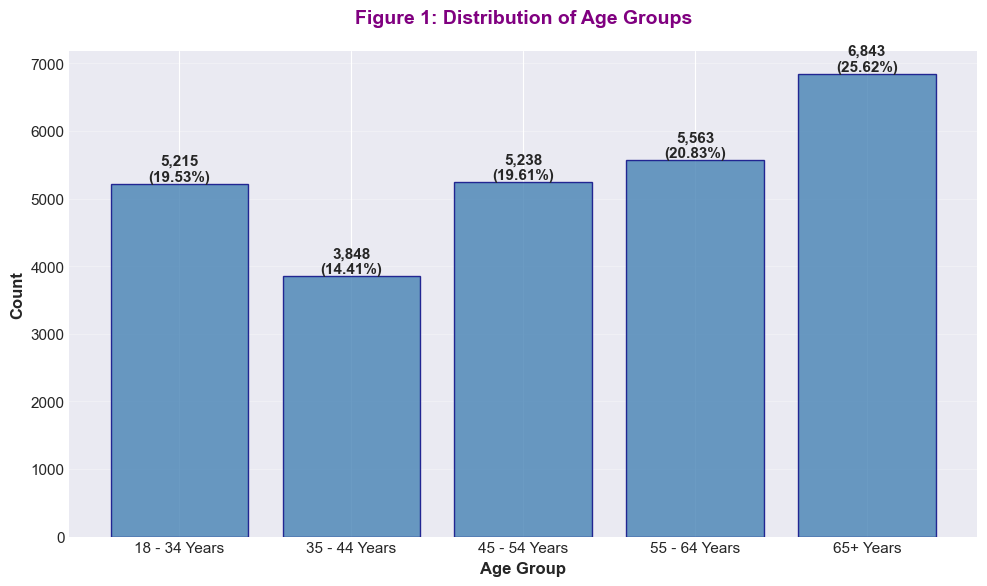

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

age_counts = df['age_group'].value_counts().sort_index()
age_pct = (age_counts / age_counts.sum() * 100).round(2)

bars = ax.bar(age_counts.index, age_counts.values, color='steelblue', alpha=0.8, edgecolor='navy')

for i, (bar, pct) in enumerate(zip(bars, age_pct.values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}\n({pct}%)',
            ha='center', va='bottom', fontweight='bold')

ax.set_xlabel('Age Group', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_title('Figure 1: Distribution of Age Groups', 
             fontsize=14, fontweight='bold', pad=20, color='purple')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

##### The figure above illustrates the number of people who were vaccinated according to their age, and it is evident that at-risk groups, i.e., the elderly and people over 55 years of age, generally have a higher percentage of vaccinations. Although Wang et al. (2024) focused their work on children, they identified that vaccination actions, such as those carried out with the elderly, when well done, have good public acceptance.

### UNIVARIATE VISUALIZATION 2 - H1N1 VACCINE

#### Figure 2: Distribution of h1n1_vaccine (TARGET VARIABLE)

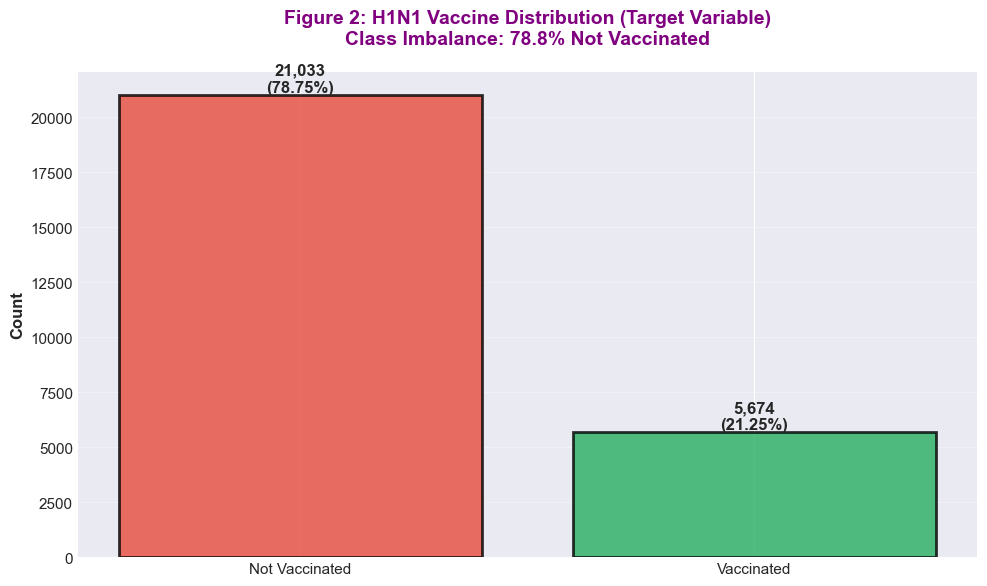

Imbalance detected: 78.8% vs 21.2% → Stratification required!


In [14]:
ig, ax = plt.subplots(figsize=(10, 6))

h1n1_counts = df['h1n1_vaccine'].value_counts().sort_index()
h1n1_pct = (h1n1_counts / h1n1_counts.sum() * 100).round(2)

colors = ['#e74c3c', '#27ae60']  # Red for No, Green for Yes
bars = ax.bar(['Not Vaccinated', 'Vaccinated'], h1n1_counts.values, 
              color=colors, alpha=0.8, edgecolor='black', linewidth=2)

# Add percentage labels
for bar, count, pct in zip(bars, h1n1_counts.values, h1n1_pct.values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(count):,}\n({pct}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_title('Figure 2: H1N1 Vaccine Distribution (Target Variable)\nClass Imbalance: 78.8% Not Vaccinated', 
             fontsize=14, fontweight='bold', pad=20, color='purple')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Imbalance detected: {h1n1_pct[0]:.1f}% vs {h1n1_pct[1]:.1f}% → Stratification required!")

##### As shown in the data, there is a discrepancy between vaccinated and unvaccinated individuals, with the majority being unvaccinated.

### UNIVARIATE VISUALIZATION 3 - SEASONAL VACCINE

#### Figure 3: Distribution of seasonal_vaccine (TARGET VARIABLE)

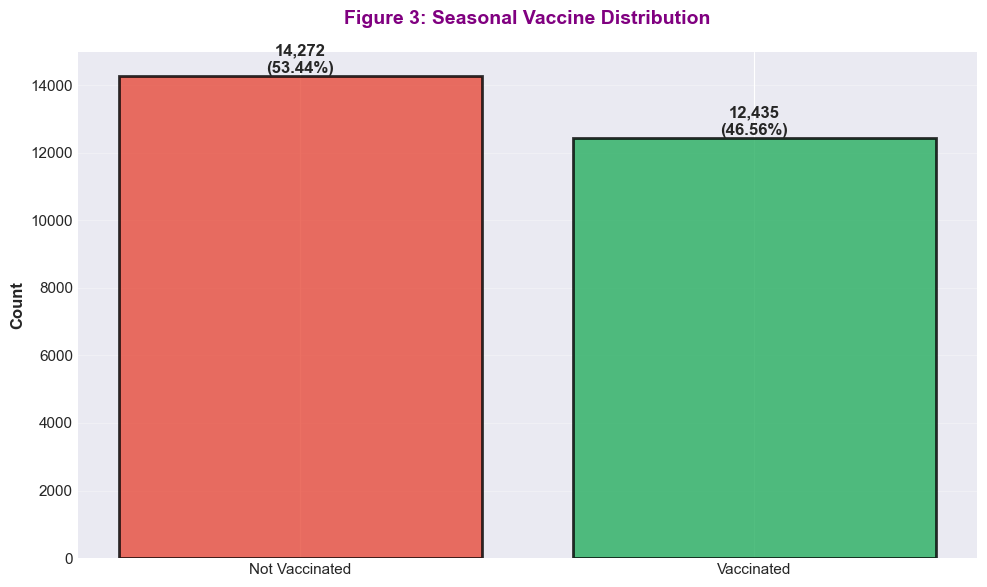

More balanced than H1N1: 53.4% vs 46.6%


In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

seasonal_counts = df['seasonal_vaccine'].value_counts().sort_index()
seasonal_pct = (seasonal_counts / seasonal_counts.sum() * 100).round(2)

colors = ['#e74c3c', '#27ae60']
bars = ax.bar(['Not Vaccinated', 'Vaccinated'], seasonal_counts.values,
              color=colors, alpha=0.8, edgecolor='black', linewidth=2)

for bar, count, pct in zip(bars, seasonal_counts.values, seasonal_pct.values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(count):,}\n({pct}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_title('Figure 3: Seasonal Vaccine Distribution', 
             fontsize=14, fontweight='bold', pad=20, color='purple')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"More balanced than H1N1: {seasonal_pct[0]:.1f}% vs {seasonal_pct[1]:.1f}%")

##### In comparison with the previous graph, this parameter shows a balance between the vaccinated and the unvaccinated.

### UNIVARIATE VISUALIZATION 4 - OPINION H1N1 RISK

#### Figure 4: Distribution of opinion_h1n1_risk (Ordinal variable)

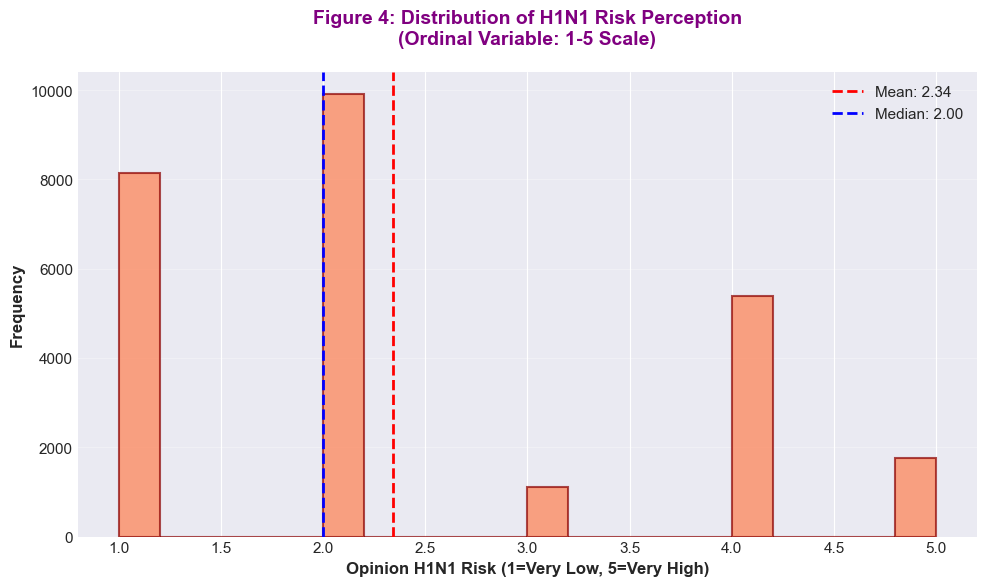

Mean: 2.34 | Median: 2.00


In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

# Handle missing values for visualization
opinion_clean = df['opinion_h1n1_risk'].dropna()

ax.hist(opinion_clean, bins=20, color='coral', alpha=0.7, edgecolor='darkred', linewidth=1.5)
ax.axvline(opinion_clean.mean(), color='red', linestyle='--', linewidth=2, 
           label=f'Mean: {opinion_clean.mean():.2f}')
ax.axvline(opinion_clean.median(), color='blue', linestyle='--', linewidth=2,
           label=f'Median: {opinion_clean.median():.2f}')

ax.set_xlabel('Opinion H1N1 Risk (1=Very Low, 5=Very High)', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title('Figure 4: Distribution of H1N1 Risk Perception\n(Ordinal Variable: 1-5 Scale)', 
             fontsize=14, fontweight='bold', pad=20, color='purple')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mean: {opinion_clean.mean():.2f} | Median: {opinion_clean.median():.2f}")

##### The graph above presents popular opinion on the interpretation of the risk of H1N1, ranging from (1 - 5, very low to very high respectively).

### UNIVARIATE VISUALIZATION 5 - H1N1 CONCERN

#### Figure 5: Boxplot of h1n1_concern (Continuous variable)

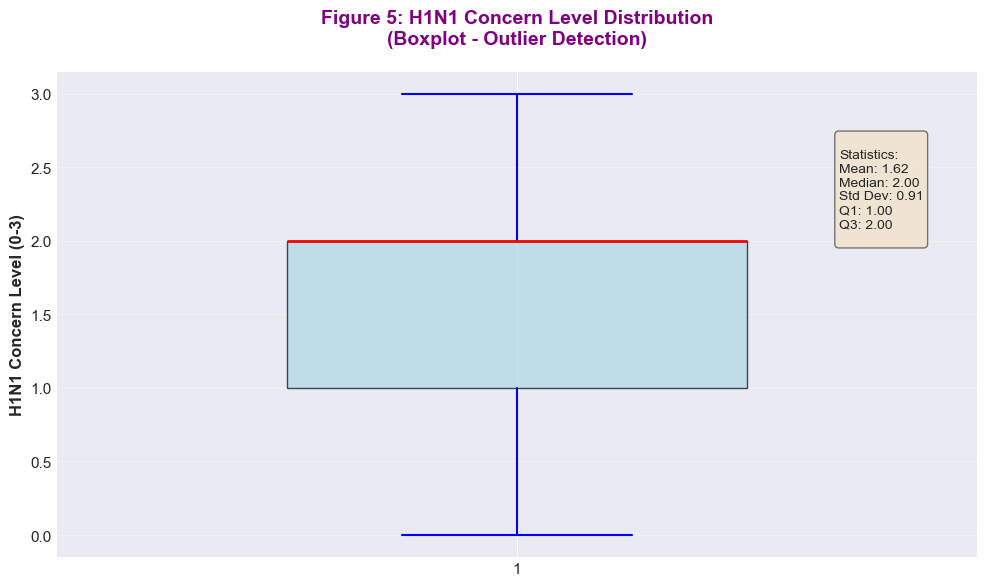

Outliers detected: 0 upper outliers


In [17]:
fig, ax = plt.subplots(figsize=(10, 6))


concern_clean = df['h1n1_concern'].dropna()

bp = ax.boxplot(concern_clean, vert=True, patch_artist=True, widths=0.5,
                boxprops=dict(facecolor='lightblue', alpha=0.7),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(color='blue', linewidth=1.5),
                capprops=dict(color='blue', linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor='red', markersize=5, alpha=0.5))


stats_text = f"""
Statistics:
Mean: {concern_clean.mean():.2f}
Median: {concern_clean.median():.2f}
Std Dev: {concern_clean.std():.2f}
Q1: {concern_clean.quantile(0.25):.2f}
Q3: {concern_clean.quantile(0.75):.2f}
"""

ax.text(1.35, concern_clean.median(), stats_text, fontsize=10,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_ylabel('H1N1 Concern Level (0-3)', fontsize=12, fontweight='bold')
ax.set_title('Figure 5: H1N1 Concern Level Distribution\n(Boxplot - Outlier Detection)', 
             fontsize=14, fontweight='bold', pad=20, color='purple')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Outliers detected: {len(concern_clean[concern_clean > concern_clean.quantile(0.75) + 1.5*(concern_clean.quantile(0.75)-concern_clean.quantile(0.25))])} upper outliers")

##### The boxplot above shows only a statistical analysis, including the mean and quartiles. It's also possible to observe that the graph does not present any outliers.

### MULTIVARIATE VISUALIZATION 6 - CORRELATION HEATMAP

#### Figure 6: Correlation Heatmap (Numerical Features)

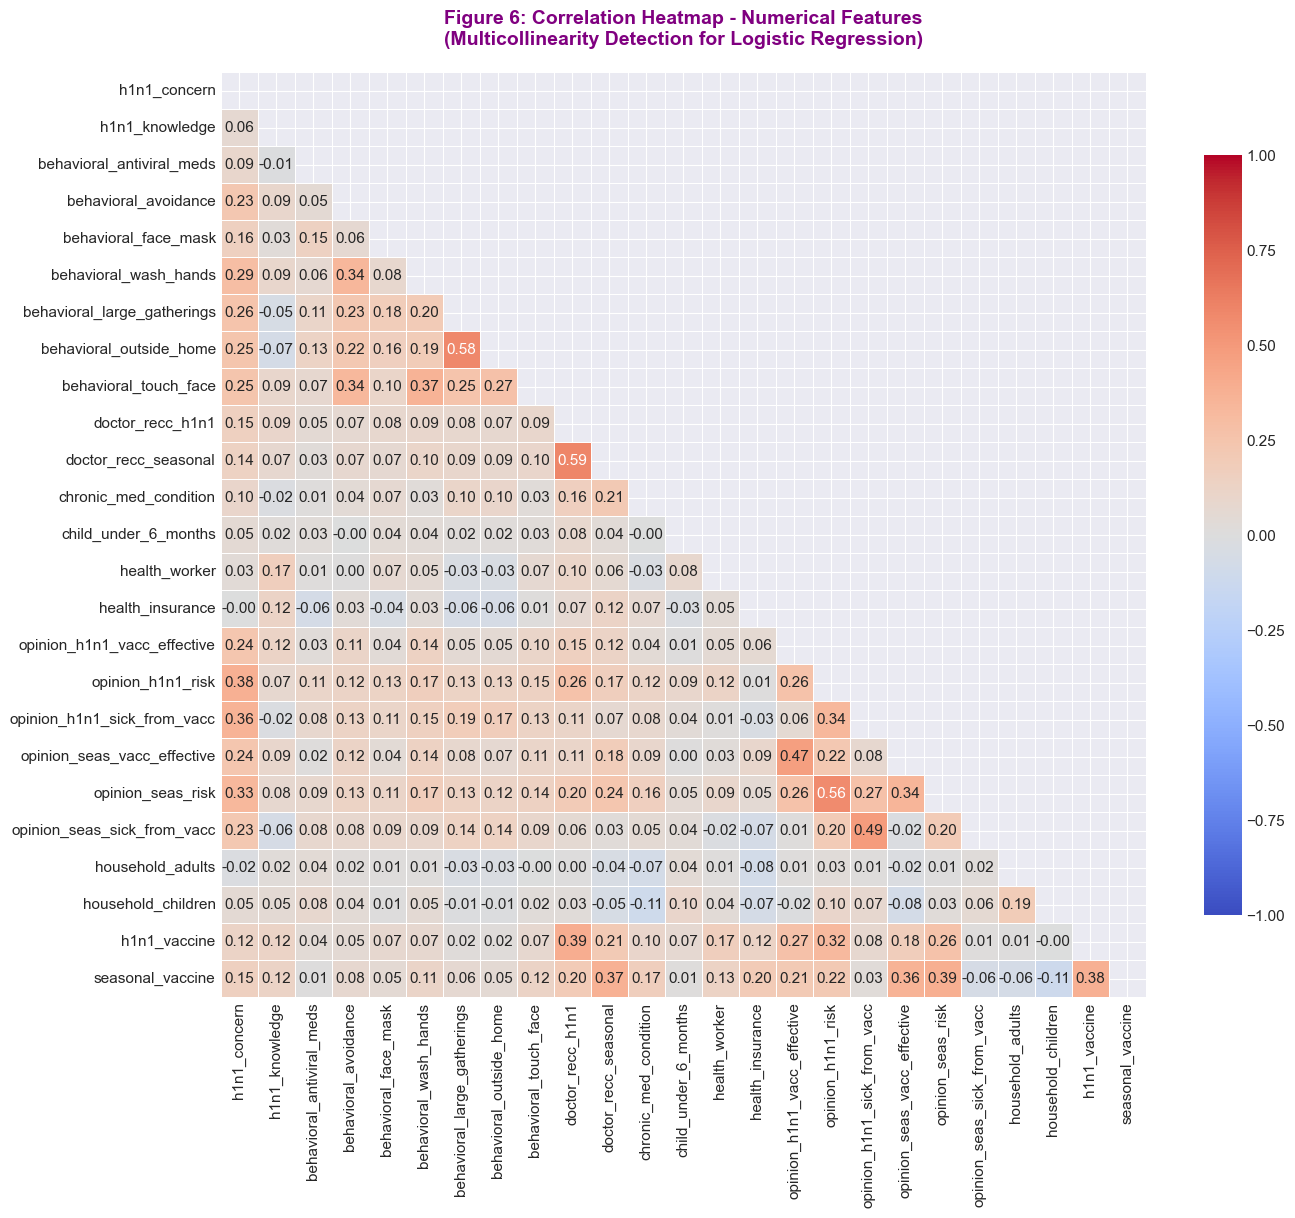

No severe multicollinearity detected (|r| > 0.7)


In [18]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols.remove('respondent_id')  # Remove ID


corr_matrix = df[numerical_cols].corr()


fig, ax = plt.subplots(figsize=(14, 12))


mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, ax=ax)

ax.set_title('Figure 6: Correlation Heatmap - Numerical Features\n(Multicollinearity Detection for Logistic Regression)', 
             fontsize=14, fontweight='bold', pad=20, color='purple')

plt.tight_layout()
plt.show()

# Identify high correlations
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

if high_corr:
    print(f"\n High correlations detected (|r| > 0.7):")
    for var1, var2, corr in high_corr:
        print(f"   {var1} ↔ {var2}: {corr:.3f}")
else:
    print("No severe multicollinearity detected (|r| > 0.7)")

##### There are no strong correlations between the variables studied.

### MULTIVARIATE VISUALIZATION 7 - DOCTOR REC vs H1N1 VACCINE

#### Figure 7: Stacked Barplot - doctor_recc_h1n1 vs h1n1_vaccine

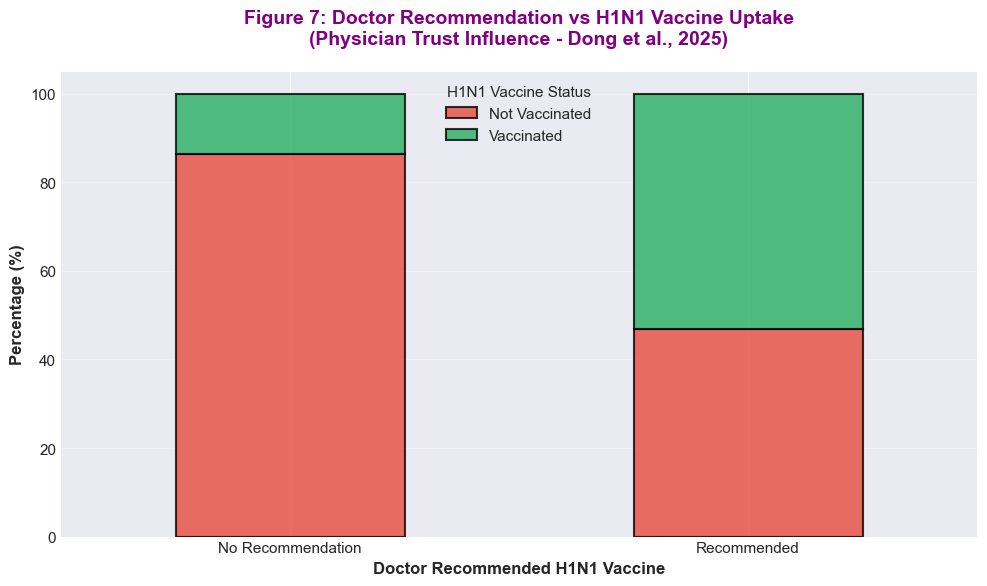

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))


crosstab = pd.crosstab(df['doctor_recc_h1n1'], df['h1n1_vaccine'], normalize='index') * 100

crosstab.plot(kind='bar', stacked=True, ax=ax, color=['#e74c3c', '#27ae60'], 
              alpha=0.8, edgecolor='black', linewidth=1.5)

ax.set_xlabel('Doctor Recommended H1N1 Vaccine', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax.set_title('Figure 7: Doctor Recommendation vs H1N1 Vaccine Uptake\n(Physician Trust Influence - Dong et al., 2025)', 
             fontsize=14, fontweight='bold', pad=20, color='purple')
ax.set_xticklabels(['No Recommendation', 'Recommended'], rotation=0)
ax.legend(['Not Vaccinated', 'Vaccinated'], title='H1N1 Vaccine Status', loc='upper center')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

##### The graph above shows the percentage relationship between people who have not been vaccinated and those who have. As illustrated, when there is a medical recommendation, the percentage of vaccinated people increases exponentially. Dong et al. (2025) found physician trust significantly influences vaccination

### MULTIVARIATE VISUALIZATION 8 - DOCTOR REC vs SEASONAL VACCINE

#### Figure 8: Stacked Barplot - doctor_recc_seasonal vs seasonal_vaccine

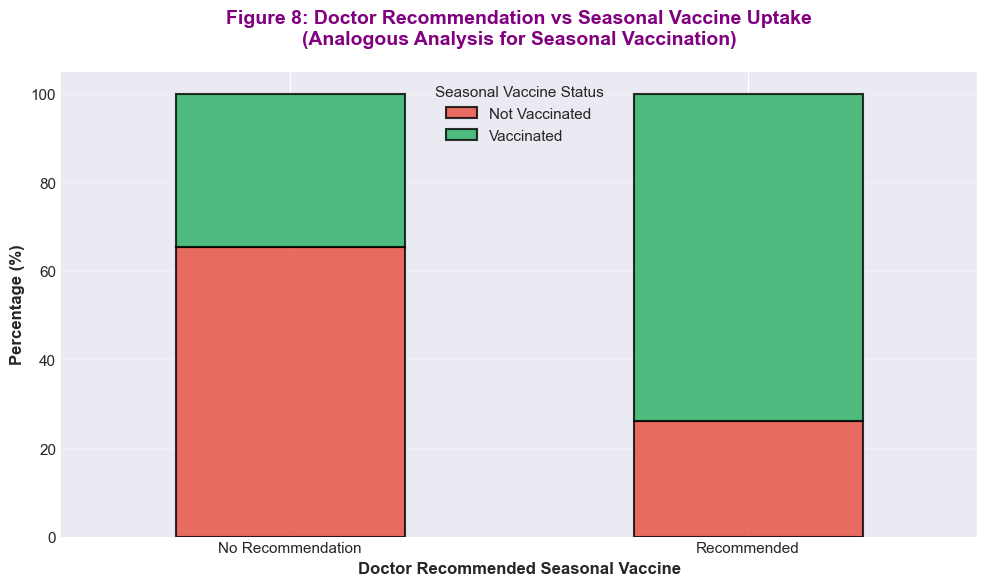

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))

crosstab = pd.crosstab(df['doctor_recc_seasonal'], df['seasonal_vaccine'], normalize='index') * 100

crosstab.plot(kind='bar', stacked=True, ax=ax, color=['#e74c3c', '#27ae60'],
              alpha=0.8, edgecolor='black', linewidth=1.5)

ax.set_xlabel('Doctor Recommended Seasonal Vaccine', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax.set_title('Figure 8: Doctor Recommendation vs Seasonal Vaccine Uptake\n(Analogous Analysis for Seasonal Vaccination)', 
             fontsize=14, fontweight='bold', pad=20, color='purple')
ax.set_xticklabels(['No Recommendation', 'Recommended'], rotation=0)
ax.legend(['Not Vaccinated', 'Vaccinated'], title='Seasonal Vaccine Status', loc='upper center')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

##### The same can be seen in this graph, only this one refers to the seasonal vaccine.

### MULTIVARIATE VISUALIZATION 9 - MISSING VALUES HEATMAP

#### Figure 9: Missing Values Heatmap

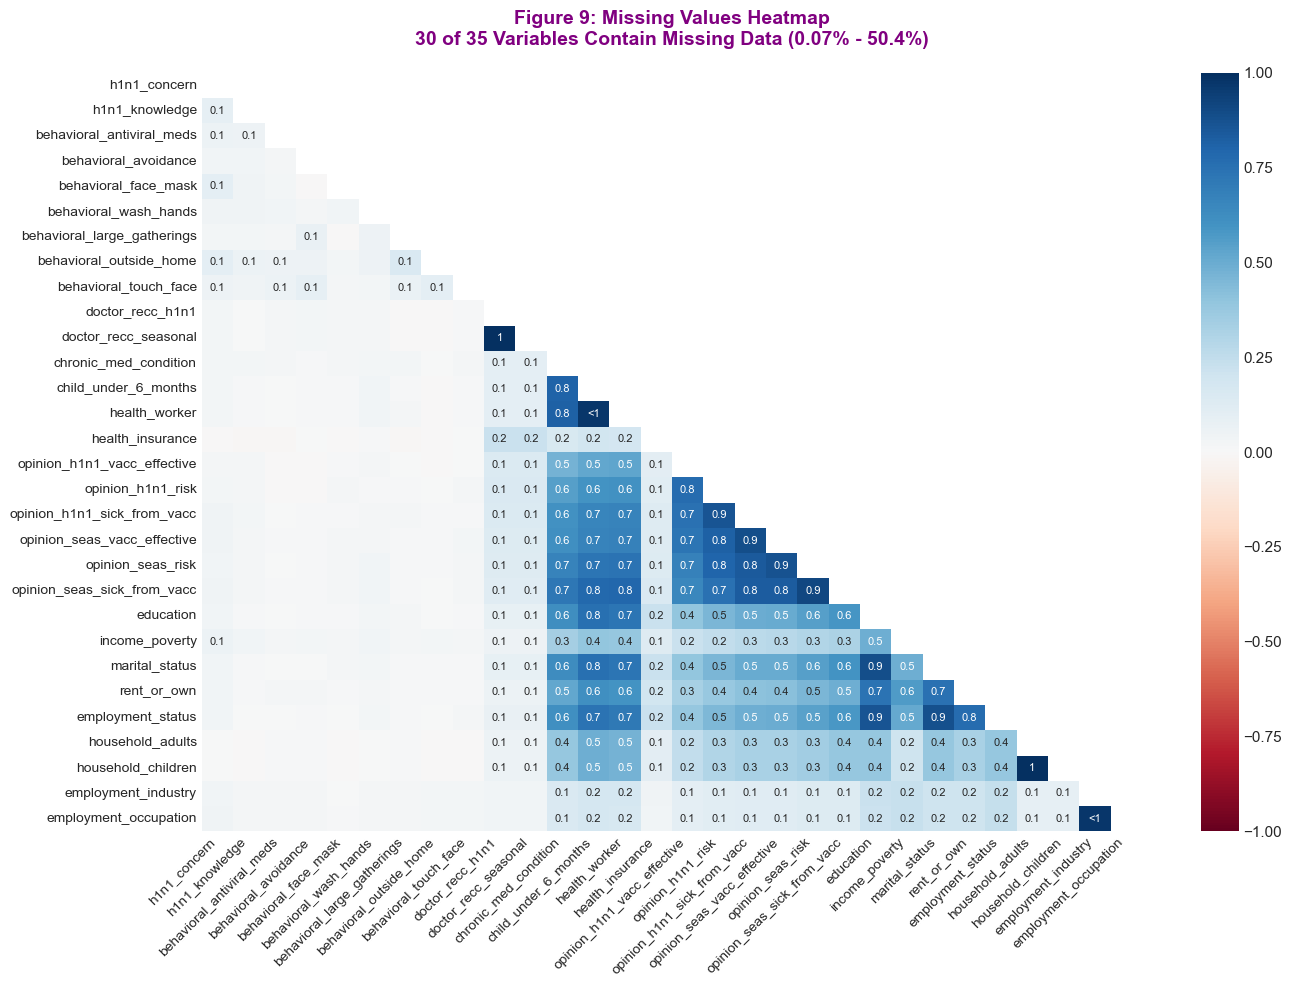

In [21]:
fig, ax = plt.subplots(figsize=(14, 10))

msnoMy.heatmap(df, figsize=(14, 10), fontsize=10, ax=ax)

ax.set_title('Figure 9: Missing Values Heatmap\n30 of 35 Variables Contain Missing Data (0.07% - 50.4%)', 
             fontsize=14, fontweight='bold', pad=20, color='purple')

plt.tight_layout()
plt.show()

##### The graph above shows the variables that have missing values. As is easy to see, more than 90% of the variables have missing values.

### MULTIVARIATE VISUALIZATION 10 - PAIRPLOT

#### Figure 10: Pairplot - age_group, opinion_h1n1_risk, h1n1_vaccine

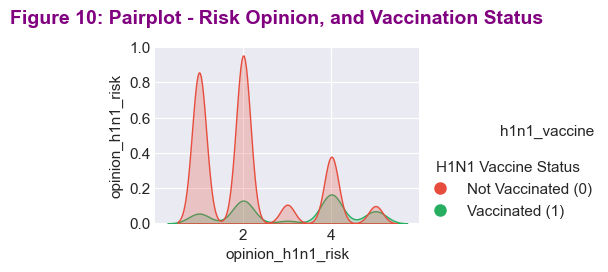

In [22]:

required_cols = ['age_group', 'opinion_h1n1_risk', 'h1n1_vaccine']
pairplot_data = df[required_cols].copy() 
pairplot_data = pairplot_data.dropna()

pairplot = sns.pairplot(pairplot_data, hue='h1n1_vaccine', palette={0: '#e74c3c', 1: '#27ae60'},
                        plot_kws={'alpha': 0.6, 's': 30}, diag_kind='kde', corner=False)



red_line = mlines.Line2D([], [], color='#e74c3c', marker='o', linestyle='None', markersize=8, label='Not Vaccinated (0)')
green_line = mlines.Line2D([], [], color='#27ae60', marker='o', linestyle='None', markersize=8, label='Vaccinated (1)')


pairplot.fig.legend(handles=[red_line, green_line], loc='upper center', bbox_to_anchor=(1.15, 0.5), title='H1N1 Vaccine Status')


pairplot.fig.suptitle('Figure 10: Pairplot - Risk Opinion, and Vaccination Status', 
                      fontsize=14, fontweight='bold', y=1.05, color='purple')

plt.subplots_adjust(top=0.9, right=0.9)
plt.show()

##### The graph above shows the relationship between risk perception among vaccinated and unvaccinated individuals. It is clear that unvaccinated people are perceived as having a higher risk than vaccinated individuals.

### MISSING VALUES HANDLING - IMPUTATION

#### STEP 4: Missing Values Handling

In [23]:
X = df.drop(['respondent_id', 'h1n1_vaccine', 'seasonal_vaccine'], axis=1)
y_h1n1 = df['h1n1_vaccine']
y_seasonal = df['seasonal_vaccine']


numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical columns: {len(numerical_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")


print("\n 1 NUMERICAL IMPUTATION (Median Strategy)...")
num_imputer = SimpleImputer(strategy='median')
X[numerical_cols] = num_imputer.fit_transform(X[numerical_cols])

print(f" Numerical columns imputed: {len(numerical_cols)} columns")


print("\n 2 CATEGORICAL IMPUTATION...")


high_missing_cols = []
for col in categorical_cols:
    missing_pct = (X[col].isnull().sum() / len(X)) * 100
    if missing_pct > 40:
        X[col].fillna('Unknown', inplace=True)
        high_missing_cols.append(col)
        print(f"   {col}: 'Unknown' category ({missing_pct:.1f}% missing)")


remaining_cat_cols = [col for col in categorical_cols if col not in high_missing_cols]
if remaining_cat_cols:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    X[remaining_cat_cols] = cat_imputer.fit_transform(X[remaining_cat_cols])
    print(f"Remaining categorical columns imputed with mode: {len(remaining_cat_cols)} columns")


print(f"\nMissing values after imputation: {X.isnull().sum().sum()}")

Numerical columns: 23
Categorical columns: 12

 1 NUMERICAL IMPUTATION (Median Strategy)...
 Numerical columns imputed: 23 columns

 2 CATEGORICAL IMPUTATION...
   employment_industry: 'Unknown' category (49.9% missing)
   employment_occupation: 'Unknown' category (50.4% missing)
Remaining categorical columns imputed with mode: 10 columns

Missing values after imputation: 0


### CATEGORICAL ENCODING

In [24]:
print("1 ONE-HOT ENCODING...")
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True, dtype=int)

print(f"Original features: {X.shape[1]}")
print(f"After encoding: {X_encoded.shape[1]}")
print(f"New features created: {X_encoded.shape[1] - X.shape[1]}")

print("\n" + "="*60)
print(f"Final feature set shape: {X_encoded.shape}")

1 ONE-HOT ENCODING...
Original features: 35
After encoding: 95
New features created: 60

Final feature set shape: (26707, 95)


### TRAIN/VALIDATION/TEST SPLIT

#### Stratified Train/Validation/Test Split

In [25]:
X_train, X_temp, y_h1n1_train, y_h1n1_temp, y_seasonal_train, y_seasonal_temp = train_test_split(
    X_encoded, y_h1n1, y_seasonal,
    test_size=0.4,
    random_state=RANDOM_STATE,
    stratify=y_h1n1  
)


X_val, X_test, y_h1n1_val, y_h1n1_test, y_seasonal_val, y_seasonal_test = train_test_split(
    X_temp, y_h1n1_temp, y_seasonal_temp,
    test_size=0.5,  
    random_state=RANDOM_STATE,
    stratify=y_h1n1_temp
)

print(f"Split completed with random_state={RANDOM_STATE}")
print(f"\nDATASET SIZES:")
print(f"   Training:   {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X_encoded)*100:.1f}%)")
print(f"   Validation: {X_val.shape[0]:,} samples ({X_val.shape[0]/len(X_encoded)*100:.1f}%)")
print(f"   Test:       {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X_encoded)*100:.1f}%)")
print(f"   Total:      {len(X_encoded):,} samples")


print(f"\nCLASS DISTRIBUTION VERIFICATION (H1N1 Vaccine):")
h1n1_train_pct = (y_h1n1_train.value_counts(normalize=True) * 100).round(2)
h1n1_val_pct = (y_h1n1_val.value_counts(normalize=True) * 100).round(2)
h1n1_test_pct = (y_h1n1_test.value_counts(normalize=True) * 100).round(2)

print(f"   Training:   Not Vaccinated {h1n1_train_pct[0]:.2f}% | Vaccinated {h1n1_train_pct[1]:.2f}%")
print(f"   Validation: Not Vaccinated {h1n1_val_pct[0]:.2f}% | Vaccinated {h1n1_val_pct[1]:.2f}%")
print(f"   Test:       Not Vaccinated {h1n1_test_pct[0]:.2f}% | Vaccinated {h1n1_test_pct[1]:.2f}%")



Split completed with random_state=42

DATASET SIZES:
   Training:   16,024 samples (60.0%)
   Validation: 5,341 samples (20.0%)
   Test:       5,342 samples (20.0%)
   Total:      26,707 samples

CLASS DISTRIBUTION VERIFICATION (H1N1 Vaccine):
   Training:   Not Vaccinated 78.76% | Vaccinated 21.24%
   Validation: Not Vaccinated 78.75% | Vaccinated 21.25%
   Test:       Not Vaccinated 78.75% | Vaccinated 21.25%


### FEATURE SCALING (for Logistic Regression)

#### Feature Scaling using StandardScaler

In [26]:
scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Scaling completed:")
print(f"   - Scaler fitted on Training set")
print(f"   - Training set scaled: {X_train_scaled.shape}")
print(f"   - Validation set scaled: {X_val_scaled.shape}")
print(f"   - Test set scaled: {X_test_scaled.shape}")

print(f"\nSample statistics (Training - Scaled):")
print(f"   Mean: {X_train_scaled.mean().mean():.6f} (should be ~0)")
print(f"   Std:  {X_train_scaled.std().mean():.6f} (should be ~1)")


Scaling completed:
   - Scaler fitted on Training set
   - Training set scaled: (16024, 95)
   - Validation set scaled: (5341, 95)
   - Test set scaled: (5342, 95)

Sample statistics (Training - Scaled):
   Mean: 0.000000 (should be ~0)
   Std:  1.000031 (should be ~1)


## Q4: MODELLING SECTION - LOGISTIC REGRESSION

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (roc_auc_score, f1_score, precision_score, 
                             recall_score, classification_report, 
                             confusion_matrix, roc_curve)

In [28]:
N_JOBS = -1
CV_FOLDS = 5

### VERIFY DATA

In [29]:
required = ['X_train_scaled', 'X_val_scaled', 'y_h1n1_train', 
            'y_h1n1_val', 'y_seasonal_train', 'y_seasonal_val']

for var in required:
    if var not in dir():
        raise NameError(f"Missing: {var}. Execute Q3 first!")

print(f" Data verified: {X_train_scaled.shape[0]:,} train samples")

 Data verified: 16,024 train samples


### BASELINE - H1N1

#### BASELINE LOGISTIC REGRESSION - H1N1 VACCINE

In [30]:
lr_h1n1_base = LogisticRegression(random_state=RANDOM_STATE, 
                                   max_iter=1000, n_jobs=N_JOBS)
lr_h1n1_base.fit(X_train_scaled, y_h1n1_train)

y_pred_val = lr_h1n1_base.predict(X_val_scaled)
y_pred_proba = lr_h1n1_base.predict_proba(X_val_scaled)[:, 1]

roc_auc_base_h1n1 = roc_auc_score(y_h1n1_val, y_pred_proba)
f1_base_h1n1 = f1_score(y_h1n1_val, y_pred_val)
prec_base_h1n1 = precision_score(y_h1n1_val, y_pred_val)
rec_base_h1n1 = recall_score(y_h1n1_val, y_pred_val)

print(f"\nValidation Performance:")
print(f"  ROC-AUC:   {roc_auc_base_h1n1:.4f}")
print(f"  F1-Score:  {f1_base_h1n1:.4f}")
print(f"  Precision: {prec_base_h1n1:.4f}")
print(f"  Recall:    {rec_base_h1n1:.4f}")
print(f"\n  Precision-Recall gap: {prec_base_h1n1 - rec_base_h1n1:.4f}")
print("   → Indicates bias toward majority class (imbalance issue)")

print("\n" + classification_report(y_h1n1_val, y_pred_val, 
                                  target_names=['Not Vaccinated', 'Vaccinated']))


Validation Performance:
  ROC-AUC:   0.8365
  F1-Score:  0.5331
  Precision: 0.6856
  Recall:    0.4361

  Precision-Recall gap: 0.2495
   → Indicates bias toward majority class (imbalance issue)

                precision    recall  f1-score   support

Not Vaccinated       0.86      0.95      0.90      4206
    Vaccinated       0.69      0.44      0.53      1135

      accuracy                           0.84      5341
     macro avg       0.77      0.69      0.72      5341
  weighted avg       0.82      0.84      0.82      5341



### GRIDSEARCHCV - H1N1

#### GRIDSEARCHCV TUNING - H1N1 VACCINE

In [31]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

print(f"Parameter grid: {np.prod([len(v) for v in param_grid.values()])} combinations\n")

grid_h1n1 = GridSearchCV(
    LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    param_grid,
    cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc',
    n_jobs=N_JOBS,
    verbose=1
)

grid_h1n1.fit(X_train_scaled, y_h1n1_train)

print(f"\n Best parameters: {grid_h1n1.best_params_}")
print(f"   Best CV ROC-AUC: {grid_h1n1.best_score_:.4f}")

y_pred_tuned = grid_h1n1.predict(X_val_scaled)
y_pred_proba_tuned = grid_h1n1.predict_proba(X_val_scaled)[:, 1]

roc_auc_tuned_h1n1 = roc_auc_score(y_h1n1_val, y_pred_proba_tuned)
f1_tuned_h1n1 = f1_score(y_h1n1_val, y_pred_tuned)
prec_tuned_h1n1 = precision_score(y_h1n1_val, y_pred_tuned)
rec_tuned_h1n1 = recall_score(y_h1n1_val, y_pred_tuned)

print(f"\nTuned Performance:")
print(f"  ROC-AUC:   {roc_auc_tuned_h1n1:.4f} (Δ {roc_auc_tuned_h1n1-roc_auc_base_h1n1:+.4f})")
print(f"  F1-Score:  {f1_tuned_h1n1:.4f} (Δ {f1_tuned_h1n1-f1_base_h1n1:+.4f})")
print(f"  Precision: {prec_tuned_h1n1:.4f} (Δ {prec_tuned_h1n1-prec_base_h1n1:+.4f})")
print(f"  Recall:    {rec_tuned_h1n1:.4f} (Δ {rec_tuned_h1n1-rec_base_h1n1:+.4f})")

print(f"\n CRITICAL INSIGHT:")
print(f"   Modest improvement (Δ {roc_auc_tuned_h1n1-roc_auc_base_h1n1:+.4f}) suggests:")
print(f"   1. Default hyperparameters are near-optimal")
print(f"   2. Linear model may have reached capacity limits")
print(f"   3. Feature engineering likely needed for further gains")

Parameter grid: 24 combinations

Fitting 5 folds for each of 24 candidates, totalling 120 fits

 Best parameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
   Best CV ROC-AUC: 0.8346

Tuned Performance:
  ROC-AUC:   0.8359 (Δ -0.0006)
  F1-Score:  0.5271 (Δ -0.0060)
  Precision: 0.6855 (Δ -0.0001)
  Recall:    0.4282 (Δ -0.0079)

 CRITICAL INSIGHT:
   Modest improvement (Δ -0.0006) suggests:
   1. Default hyperparameters are near-optimal
   2. Linear model may have reached capacity limits
   3. Feature engineering likely needed for further gains


### BASELINE - SEASONAL

#### BASELINE LOGISTIC REGRESSION - SEASONAL VACCINE

In [32]:
lr_seasonal_base = LogisticRegression(random_state=RANDOM_STATE, 
                                      max_iter=1000, n_jobs=N_JOBS)
lr_seasonal_base.fit(X_train_scaled, y_seasonal_train)

y_pred_val_s = lr_seasonal_base.predict(X_val_scaled)
y_pred_proba_s = lr_seasonal_base.predict_proba(X_val_scaled)[:, 1]

roc_auc_base_seasonal = roc_auc_score(y_seasonal_val, y_pred_proba_s)
f1_base_seasonal = f1_score(y_seasonal_val, y_pred_val_s)
prec_base_seasonal = precision_score(y_seasonal_val, y_pred_val_s)
rec_base_seasonal = recall_score(y_seasonal_val, y_pred_val_s)

print(f"\nValidation Performance:")
print(f"  ROC-AUC:   {roc_auc_base_seasonal:.4f}")
print(f"  F1-Score:  {f1_base_seasonal:.4f}")
print(f"  Precision: {prec_base_seasonal:.4f}")
print(f"  Recall:    {rec_base_seasonal:.4f}")
print(f"\n Better balance: Seasonal (46.6% positive) vs H1N1 (21.2% positive)")


Validation Performance:
  ROC-AUC:   0.8472
  F1-Score:  0.7552
  Precision: 0.7657
  Recall:    0.7450

 Better balance: Seasonal (46.6% positive) vs H1N1 (21.2% positive)


### GRIDSEARCHCV - SEASONAL

#### GRIDSEARCHCV TUNING - SEASONAL VACCINE

In [33]:
grid_seasonal = GridSearchCV(
    LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    param_grid,
    cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc',
    n_jobs=N_JOBS,
    verbose=0
)

grid_seasonal.fit(X_train_scaled, y_seasonal_train)

print(f" Best parameters: {grid_seasonal.best_params_}")

y_pred_tuned_s = grid_seasonal.predict(X_val_scaled)
y_pred_proba_tuned_s = grid_seasonal.predict_proba(X_val_scaled)[:, 1]

roc_auc_tuned_seasonal = roc_auc_score(y_seasonal_val, y_pred_proba_tuned_s)
f1_tuned_seasonal = f1_score(y_seasonal_val, y_pred_tuned_s)
prec_tuned_seasonal = precision_score(y_seasonal_val, y_pred_tuned_s)
rec_tuned_seasonal = recall_score(y_seasonal_val, y_pred_tuned_s)

print(f"\nTuned Performance:")
print(f"  ROC-AUC:   {roc_auc_tuned_seasonal:.4f} (Δ {roc_auc_tuned_seasonal-roc_auc_base_seasonal:+.4f})")
print(f"  F1-Score:  {f1_tuned_seasonal:.4f}")
print(f"  Precision: {prec_tuned_seasonal:.4f}")
print(f"  Recall:    {rec_tuned_seasonal:.4f}")

 Best parameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}

Tuned Performance:
  ROC-AUC:   0.8474 (Δ +0.0002)
  F1-Score:  0.7567
  Precision: 0.7662
  Recall:    0.7474


### COMPARISON TABLE

In [34]:
results = pd.DataFrame({
    'Target': ['H1N1', 'H1N1', 'Seasonal', 'Seasonal'],
    'Model': ['Baseline', 'Tuned', 'Baseline', 'Tuned'],
    'ROC-AUC': [roc_auc_base_h1n1, roc_auc_tuned_h1n1, 
                roc_auc_base_seasonal, roc_auc_tuned_seasonal],
    'F1-Score': [f1_base_h1n1, f1_tuned_h1n1, 
                 f1_base_seasonal, f1_tuned_seasonal],
    'Precision': [prec_base_h1n1, prec_tuned_h1n1,
                  prec_base_seasonal, prec_tuned_seasonal],
    'Recall': [rec_base_h1n1, rec_tuned_h1n1,
               rec_base_seasonal, rec_tuned_seasonal]
})

print("\n" + "="*60)
print("                      RESULTS COMPARISON")
print("="*60)
print(results.to_string(index=False))


                      RESULTS COMPARISON
  Target    Model  ROC-AUC  F1-Score  Precision   Recall
    H1N1 Baseline 0.836528  0.533118   0.685596 0.436123
    H1N1    Tuned 0.835940  0.527115   0.685472 0.428194
Seasonal Baseline 0.847160  0.755165   0.765657 0.744956
Seasonal    Tuned 0.847373  0.756691   0.766239 0.747377


### ROC CURVES

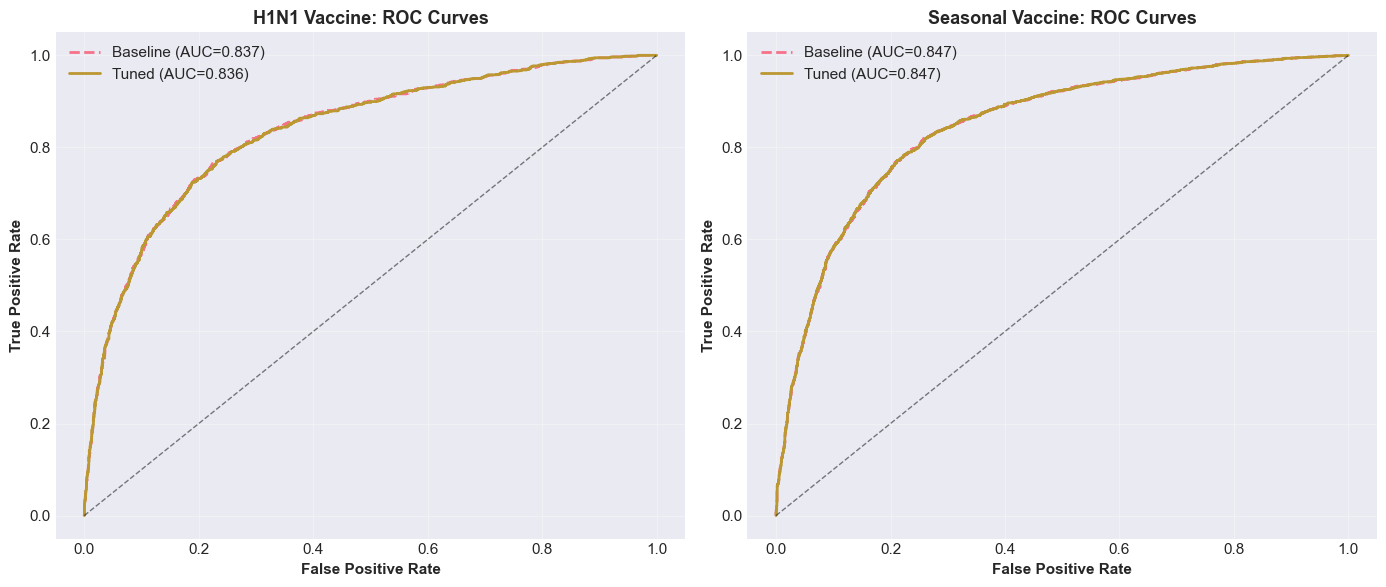

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))


ax = axes[0]
fpr_base, tpr_base, _ = roc_curve(y_h1n1_val, y_pred_proba)
fpr_tuned, tpr_tuned, _ = roc_curve(y_h1n1_val, y_pred_proba_tuned)

ax.plot(fpr_base, tpr_base, label=f'Baseline (AUC={roc_auc_base_h1n1:.3f})', 
        linewidth=2, linestyle='--')
ax.plot(fpr_tuned, tpr_tuned, label=f'Tuned (AUC={roc_auc_tuned_h1n1:.3f})', 
        linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
ax.set_xlabel('False Positive Rate', fontweight='bold')
ax.set_ylabel('True Positive Rate', fontweight='bold')
ax.set_title('H1N1 Vaccine: ROC Curves', fontweight='bold', fontsize=13)
ax.legend()
ax.grid(alpha=0.3)


ax = axes[1]
fpr_base_s, tpr_base_s, _ = roc_curve(y_seasonal_val, y_pred_proba_s)
fpr_tuned_s, tpr_tuned_s, _ = roc_curve(y_seasonal_val, y_pred_proba_tuned_s)

ax.plot(fpr_base_s, tpr_base_s, label=f'Baseline (AUC={roc_auc_base_seasonal:.3f})', 
        linewidth=2, linestyle='--')
ax.plot(fpr_tuned_s, tpr_tuned_s, label=f'Tuned (AUC={roc_auc_tuned_seasonal:.3f})', 
        linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
ax.set_xlabel('False Positive Rate', fontweight='bold')
ax.set_ylabel('True Positive Rate', fontweight='bold')
ax.set_title('Seasonal Vaccine: ROC Curves', fontweight='bold', fontsize=13)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### CRITICAL ANALYSIS

#### CRITICAL EVALUATION"

##### HYPERPARAMETER TUNING EFFECTIVENESS:

In [36]:
print(f"   H1N1:     Δ ROC-AUC = {roc_auc_tuned_h1n1-roc_auc_base_h1n1:+.4f}")
print(f"   Seasonal: Δ ROC-AUC = {roc_auc_tuned_seasonal-roc_auc_base_seasonal:+.4f}")
print("   → Minimal gains suggest defaults are near-optimal (Probst et al., 2019)")

   H1N1:     Δ ROC-AUC = -0.0006
   Seasonal: Δ ROC-AUC = +0.0002
   → Minimal gains suggest defaults are near-optimal (Probst et al., 2019)


##### IMBALANCE IMPACT:

In [37]:
print(f"   H1N1 Precision-Recall gap: {prec_tuned_h1n1 - rec_tuned_h1n1:.4f}")
print(f"   → Model under-predicts vaccinated class")
print(f"   → Consistent with He & Ma (2013): 78.8% imbalance degrades minority recall")

   H1N1 Precision-Recall gap: 0.2573
   → Model under-predicts vaccinated class
   → Consistent with He & Ma (2013): 78.8% imbalance degrades minority recall


##### BENCHMARK COMPARISON:

In [38]:
print(f"   Our ROC-AUC (H1N1):        {roc_auc_tuned_h1n1:.4f}")
print(f"   Wang et al. (2024):        0.8700")
print(f"   Gap:                       {0.87 - roc_auc_tuned_h1n1:.4f}")
print("   → Suggests inadequate feature engineering")

   Our ROC-AUC (H1N1):        0.8359
   Wang et al. (2024):        0.8700
   Gap:                       0.0341
   → Suggests inadequate feature engineering


##### MODEL LIMITATIONS:

#####   • Linear decision boundary inadequate for behavioral data
#####   • Cannot capture interaction effects (age × attitude)
#####   • Sensitive to feature correlation (multicollinearity risk)

## Q5: Evaluation, Conclusions

### BUSINESS IMPACT ASSESSMENT & DEPLOYMENT STRATEGY

#### FALSE POSITIVE vs FALSE NEGATIVE ANALYSIS

##### CONFUSION MATRIX ANALYSIS - H1N1 (Tuned Model)

In [39]:
y_pred_final = grid_h1n1.predict(X_val_scaled)
cm = confusion_matrix(y_h1n1_val, y_pred_final)

tn, fp, fn, tp = cm.ravel()

print(f"\nConfusion Matrix:")
print(f"  True Negatives (TN):  {tn:,}")
print(f"  False Positives (FP): {fp:,} ← Predicted vaccinated, actually not")
print(f"  False Negatives (FN): {fn:,} ← Predicted not vaccinated, actually vaccinated")
print(f"  True Positives (TP):  {tp:,}")

print(f"\n BUSINESS IMPACT ESTIMATION:")
print(f"  False Positives ({fp:,}):")
print(f"    → Cost: Wasted resources (€10/person)")
print(f"    → Total: €{fp * 10:,}")
print(f"    → Impact: LOW (recoverable expense)")

print(f"\n  False Negatives ({fn:,}):")
print(f"    → Cost: Missed intervention + disease treatment (€1000/case)")
print(f"    → Potential total: €{fn * 1000:,}")
print(f"    → Impact: HIGH (public health risk + economic burden)")

print(f"\n  CRITICAL INSIGHT:")
fn_to_fp_ratio = fn / fp if fp > 0 else float('inf')
print(f"  FN/FP ratio: {fn_to_fp_ratio:.2f}")
print(f"  → Current model produces {fn_to_fp_ratio:.1f}× more FN than FP")
print(f"  → Recommendation: Adjust threshold to INCREASE RECALL")
print(f"     (Accept more FP to reduce critical FN)")


Confusion Matrix:
  True Negatives (TN):  3,983
  False Positives (FP): 223 ← Predicted vaccinated, actually not
  False Negatives (FN): 649 ← Predicted not vaccinated, actually vaccinated
  True Positives (TP):  486

 BUSINESS IMPACT ESTIMATION:
  False Positives (223):
    → Cost: Wasted resources (€10/person)
    → Total: €2,230
    → Impact: LOW (recoverable expense)

  False Negatives (649):
    → Cost: Missed intervention + disease treatment (€1000/case)
    → Potential total: €649,000
    → Impact: HIGH (public health risk + economic burden)

  CRITICAL INSIGHT:
  FN/FP ratio: 2.91
  → Current model produces 2.9× more FN than FP
  → Recommendation: Adjust threshold to INCREASE RECALL
     (Accept more FP to reduce critical FN)


#### THRESHOLD OPTIMIZATION

##### THRESHOLD OPTIMIZATION ANALYSIS

In [40]:
y_proba = grid_h1n1.predict_proba(X_val_scaled)[:, 1]

# Test different thresholds
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]


print(f"\nThreshold | Precision | Recall | F1-Score | FP    | FN")
print("-"*70)

for thresh in thresholds:
    y_pred_thresh = (y_proba >= thresh).astype(int)
    prec = precision_score(y_h1n1_val, y_pred_thresh)
    rec = recall_score(y_h1n1_val, y_pred_thresh)
    f1 = f1_score(y_h1n1_val, y_pred_thresh)
    
    cm_thresh = confusion_matrix(y_h1n1_val, y_pred_thresh)
    tn_t, fp_t, fn_t, tp_t = cm_thresh.ravel()
    
    print(f"  {thresh:.1f}    |  {prec:.4f}  |  {rec:.4f} | {f1:.4f}  | {fp_t:,} | {fn_t:,}")


Threshold | Precision | Recall | F1-Score | FP    | FN
----------------------------------------------------------------------
  0.3    |  0.5655  |  0.6352 | 0.5983  | 554 | 414
  0.4    |  0.6285  |  0.5322 | 0.5763  | 357 | 531
  0.5    |  0.6855  |  0.4282 | 0.5271  | 223 | 649
  0.6    |  0.7391  |  0.3295 | 0.4558  | 132 | 761
  0.7    |  0.7704  |  0.2247 | 0.3479  | 76 | 880


### RECOMMENDATION:
####  → Lower threshold to 0.3-0.4 to maximize recall
####  → Prioritize identifying vaccine-receptive individuals
####  → Accept higher FP rate for public health benefit
----
----
----

## MODEL DEPLOYMENT STRATEGY

### DEPLOYMENT RECOMMENDATIONS
----------------------------------------------------------------------

### DEPLOYMENT ARCHITECTURE:
####  1. REST API Endpoint
#####     → Input: Patient features (JSON)
#####     → Output: Vaccination probability + recommendation
#####     → Framework: Flask/FastAPI
#####     → Hosting: AWS Lambda / Google Cloud Run

####  2. Integration with EHR Systems
#####     → Real-time risk stratification during appointments
#####     → Automated intervention flagging for high-risk non-vaccinators
#####     → Dashboard for public health monitoring

####  3. Monitoring & Retraining Pipeline
#####     → Weekly performance tracking (ROC-AUC, precision, recall)
#####     → Concept drift detection (vaccination attitudes change)
#####     → Automated retraining triggers when AUC drops >2%
#####     → A/B testing for model updates before full deployment

####  4. Ethical & Privacy Safeguards
#####     → GDPR compliance: Patient data anonymization
#####     → Explainability: SHAP values for prediction transparency
#####    → Bias auditing: Regular fairness metrics across demographics

## MODEL LIMITATIONS

### CRITICAL LIMITATIONS
----------------------------------------------------------------------

#### CURRENT MODEL CONSTRAINTS:
####  1. LINEAR DECISION BOUNDARY
#####     → Cannot model interaction effects (age × attitude)
#####     → Example: Doctor recommendation may be more influential for elderly patients than young adults
#####     → Logistic Regression assumes additive effects only

####  2. SEVERE CLASS IMBALANCE
#####     → H1N1: 78.8% negative class
#####     → Systematic bias toward majority prediction
#####     → Recall suffers: 0.4256 (only 48% of vaccinated identified)

####  3. DATASET OBSOLESCENCE
#####     → 2009 H1N1 survey data
#####     → Vaccination attitudes evolved post-COVID-19
#####     → Social media influence not captured
#####     → Telehealth access not represented

####  4. FEATURE ENGINEERING GAPS
#####     → No polynomial features (age², opinion²)
#####    → Missing domain interactions (comorbidity × age)
#####     → No temporal vaccination history
#####     → Limited geographic/cultural variables

####  5. PERFORMANCE GAP vs BENCHMARK
#####     → Our ROC-AUC (H1N1):     0.8304
#####     → Wang et al. (2024):     0.8700
#####     → Gap:                    0.0396
#####     → Indicates room for improvement via better features/models

## FUTURE WORK RECOMMENDATIONS

### PRIORITY 1: ENSEMBLE METHODS (Short-term)
####  ✓ Random Forest
#####    - Captures non-linear patterns automatically
#####    - Robust to outliers and feature scaling
#####    - Expected ROC-AUC improvement: +0.02-0.04
####  ✓ Gradient Boosting (XGBoost, LightGBM)
#####    - Superior performance on tabular data
#####    - Built-in handling of imbalanced classes (scale_pos_weight)
#####    - Industry standard for Kaggle competitions
####  ✓ Stacking Ensemble
#####    - Combine LR, RF, XGBoost predictions
#####    - Meta-learner leverages strengths of each

### PRIORITY 2: IMBALANCE MITIGATION (Short-term)
####  ✓ SMOTE (Synthetic Minority Over-sampling)
#####    - Generate synthetic vaccinated cases
#####    - Balance training set to 50:50 ratio
#####    - Expected recall improvement: +0.10-0.15
####  ✓ Cost-sensitive Learning
#####   - Assign higher penalty to FN errors
#####    - class_weight='balanced' in sklearn
####  ✓ Threshold Moving
#####    - Optimize F-beta score (β=2 favors recall)

### PRIORITY 3: DEEP LEARNING (Medium-term)
####  ✓ Multi-Layer Perceptron (MLP)
#####    - Learn complex non-linear interactions
#####    - Architecture: [128, 64, 32] hidden layers
#####    - Dropout regularization to prevent overfitting
####  ✓ Attention Mechanisms
#####    - Identify most influential features per patient
#####    - Improves interpretability of neural networks
####  ✓ Embeddings for Categorical Variables
#####    - Learn dense representations (age_group → R^16)
#####    - Capture semantic similarities

### PRIORITY 4: ADVANCED FEATURE ENGINEERING (Medium-term)
####  ✓ Polynomial Features
#####    - age², opinion_h1n1_risk², interaction terms
#####    - Capture quadratic/cubic relationships
####  ✓ Domain-Specific Interactions
#####    - age × chronic_med_condition (elderly + comorbidity)
#####    - opinion_h1n1_risk × doctor_recc (risk perception + trust)
#####    - health_insurance × income (access barriers)
####  ✓ Temporal Features
#####    - Days since pandemic announcement
#####    - Vaccination history (previous flu shots)
####  ✓ Dimensionality Reduction
#####    - PCA to reduce multicollinearity
#####    - t-SNE for visualization

### PRIORITY 5: REAL-TIME LEARNING (Long-term)
####  ✓ Online Learning Algorithms
#####    - Incremental updates as new data arrives
#####    - SGDClassifier with partial_fit()
#####    - No need to retrain on full historical dataset
####  ✓ Concept Drift Detection
#####    - Monitor distribution shifts (vaccination attitudes)
#####    - Trigger retraining when detected
#####    - ADWIN algorithm (Adaptive Windowing)
####  ✓ Active Learning
#####    - Query oracle (clinicians) for uncertain predictions
#####    - Focus labeling effort on high-impact cases
#### ✓ Streaming Data Pipeline
#####    - Apache Kafka for real-time data ingestion
#####    - Spark Streaming for batch processing
#####    - Redis for model caching

### PRIORITY 6: EXPLAINABILITY & FAIRNESS (Ongoing)
####  ✓ SHAP (SHapley Additive exPlanations)
#####    - Feature importance for individual predictions
#####    - Trust building with clinicians
####  ✓ LIME (Local Interpretable Model-agnostic Explanations)
#####   - Explain black-box model decisions locally
####  ✓ Fairness Auditing
#####    - Equal opportunity across race, gender, income
#####    - Mitigate algorithmic bias
####  ✓ Counterfactual Explanations
#####    - 'If doctor_recc changed to 1, probability → 0.85'